# Métodos Numéricos (Bisección y Newton-Raphson)
## Cálculo Multivariable

In [38]:
import sympy as sp              # Cálculo simbólico
import numpy as np              # Cálculo numérico
import matplotlib.pyplot as plt # Gráficas
from tabulate import tabulate   # Tablas de resultados

# Variable simbólica usada en todo el notebook
x = sp.symbols('x')

# Funciones principales del examen (simbólicas)
f = x**3 - x - 2     # f(x) = x^3 - x - 2
g = sp.exp(-x) - x   # g(x) = e^(-x) - x

print("Funciones definidas:")
sp.pprint(sp.Eq(sp.Function('f')(x), f))
sp.pprint(sp.Eq(sp.Function('g')(x), g))

Funciones definidas:
        3        
f(x) = x  - x - 2
             -x
g(x) = -x + ℯ  


## Funciones auxiliares (reutilizables)

Se adaptan las funciones de clase `MetodoBiseccion` y `MetodoNewton`. Se les agrega:

- Un parámetro `max_iter` para **detectar la no convergencia** (ciclos o divergencia).
- La opción de recibir una **derivada propia** (útil para funciones por tramos).
- El retorno de la **raíz estimada** y del **número de pasos** para poder comparar métodos.

In [39]:
# ============================================================
# IMPORTACIONES Y DEFINICIÓN DE LOS MÉTODOS NUMÉRICOS
# ============================================================
import sympy as sp
import numpy as np
from tabulate import tabulate

x = sp.symbols('x')

# ----------------------------------------------------------
# Método de Bisección
# ----------------------------------------------------------
def MetodoBiseccion(Funcion, xizq, xder, tolerancia=1e-6, MaxPasos=100):

    Funcion = sp.lambdify(x, Funcion)   # Evaluación numérica
    fa = Funcion(xizq)
    fb = Funcion(xder)
    Pasos = 0
    ErrorAprox = 2
    Tabla = []

    print('\nTabla de Resultados del Método de Bisección')

    while ErrorAprox > tolerancia and Pasos < MaxPasos:

        xc = 0.5 * (xizq + xder)
        fc = Funcion(xc)
        Pasos += 1
        ErrorAprox = abs(xder - xizq) / 2

        Tabla.append([Pasos, xizq, xc, xder, fa, fc, fb, ErrorAprox])

        if abs(fa) < 1e-16:
            xc = xizq
            print('\n La raíz se encuentra en el extremo izquierdo:', xizq)
            break

        if abs(fb) < 1e-16:
            xc = xder
            print('\n La raíz se encuentra en el extremo derecho:', xder)
            break

        if fa * fc < 0:
            xder = xc
            fb = fc
        elif fc * fb < 0:
            xizq = xc
            fa = fc
        else:
            print('El Método de Bisección falla: no hay cambio de signo en el intervalo.\n')
            break

    print(tabulate(Tabla,
                   headers=['Paso', 'a', 'c', 'b', 'f(a)', 'f(c)', 'f(b)', 'Error Aprox'],
                   floatfmt=['3d', '11.8f', '11.8f', '11.8f', '8.2e', '8.2e', '8.2e', '8.2e'],
                   tablefmt='rounded_grid',
                   numalign='center'))

    print('\n Después de {:3d} pasos, la raíz aproximada con Bisección es:  {:18.15f}\n'.format(Pasos, xc))
    return xc


# ----------------------------------------------------------
# Método de Newton
# ----------------------------------------------------------
def MetodoNewton(Funcion, xest=0.0, TOL=1e-10, MaxPasos=100):

    Derivada = sp.diff(Funcion, x)
    print()
    print('La función derivada obtenida con sympy es:')
    sp.pprint(Derivada)
    print()

    Funcion  = sp.lambdify(x, Funcion)
    Derivada = sp.lambdify(x, Derivada)

    Pasos = 0
    Error = 2
    Tabla = []

    print('\nTabla de Resultados del Método de Newton')

    while Error > TOL and Pasos < MaxPasos:
        Pasos += 1
        fxo  = Funcion(xest)
        dfxo = Derivada(xest)
        x1   = xest - fxo / dfxo
        Error = abs(xest - x1)
        xest  = x1
        Tabla.append([Pasos, xest, Error])

    print(tabulate(Tabla,
                   headers=['Paso', 'Estimación', 'Error Aproximado'],
                   floatfmt=['3d', '18.14f', '8.2e'],
                   tablefmt='rounded_grid',
                   numalign='center'))

    if Pasos >= MaxPasos:
        print('El Método de Newton NO pudo aproximar una raíz. Intente con otra estimación.\n')
    else:
        print('Después de {:2d} pasos, la raíz aproximada con Newton es: {:18.15f}\n'.format(Pasos, xest))

    print()
    return xest

## Tema 1 — Bisección y Newton para $f$ y $g$  (20 pts)
$f(x)=x^3-x-2$ en $[1,2]$

Funciones del problema 1:
f(x) = 
 3        
x  - x - 2
g(x) = 
      -x
-x + ℯ  


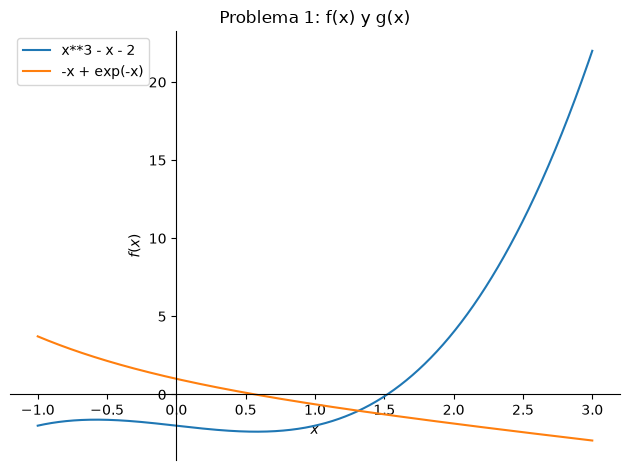

In [40]:
f = x**3 - x - 2
g = sp.exp(-x) - x

print('Funciones del problema 1:')
print('f(x) = '), sp.pprint(f)
print('g(x) = '), sp.pprint(g)

# Graficamos para identificar los intervalos con raíces
p1 = sp.plot(f, g, (x, -1, 3),
             legend=True, title='Problema 1: f(x) y g(x)',
             show=True)

### Tema 1 — $g(x)=e^{-x}-x$ en $[0,1]$

In [42]:
TOL4 = 5e-5   # Precisión de 4 decimales


print('BISECCIÓN — f(x) = x³ - x - 2,  intervalo [1, 2]')

raiz_f_bis = MetodoBiseccion(f, 1, 2, tolerancia=TOL4)

BISECCIÓN — f(x) = x³ - x - 2,  intervalo [1, 2]

Tabla de Resultados del Método de Bisección
╭────────┬────────────┬────────────┬────────────┬───────────┬───────────┬──────────┬───────────────╮
│  Paso  │     a      │     c      │     b      │   f(a)    │   f(c)    │   f(b)   │  Error Aprox  │
├────────┼────────────┼────────────┼────────────┼───────────┼───────────┼──────────┼───────────────┤
│   1    │ 1.00000000 │ 1.50000000 │ 2.00000000 │ -2.00e+00 │ -1.25e-01 │ 4.00e+00 │   5.00e-01    │
├────────┼────────────┼────────────┼────────────┼───────────┼───────────┼──────────┼───────────────┤
│   2    │ 1.50000000 │ 1.75000000 │ 2.00000000 │ -1.25e-01 │ 1.61e+00  │ 4.00e+00 │   2.50e-01    │
├────────┼────────────┼────────────┼────────────┼───────────┼───────────┼──────────┼───────────────┤
│   3    │ 1.50000000 │ 1.62500000 │ 1.75000000 │ -1.25e-01 │ 6.66e-01  │ 1.61e+00 │   1.25e-01    │
├────────┼────────────┼────────────┼────────────┼───────────┼───────────┼──────────┼──────────────

In [43]:

print('NEWTON — f(x) = x³ - x - 2,  x0 = 1')

raiz_f_new = MetodoNewton(f, xest=1.0, TOL=TOL4)

NEWTON — f(x) = x³ - x - 2,  x0 = 1

La función derivada obtenida con sympy es:
   2    
3⋅x  - 1


Tabla de Resultados del Método de Newton
╭────────┬──────────────────┬────────────────────╮
│  Paso  │    Estimación    │  Error Aproximado  │
├────────┼──────────────────┼────────────────────┤
│   1    │ 2.00000000000000 │      1.00e+00      │
├────────┼──────────────────┼────────────────────┤
│   2    │ 1.63636363636364 │      3.64e-01      │
├────────┼──────────────────┼────────────────────┤
│   3    │ 1.53039205213118 │      1.06e-01      │
├────────┼──────────────────┼────────────────────┤
│   4    │ 1.52144146513514 │      8.95e-03      │
├────────┼──────────────────┼────────────────────┤
│   5    │ 1.52137970973315 │      6.18e-05      │
├────────┼──────────────────┼────────────────────┤
│   6    │ 1.52137970680457 │      2.93e-09      │
╰────────┴──────────────────┴────────────────────╯
Después de  6 pasos, la raíz aproximada con Newton es:  1.521379706804568




In [44]:

print('BISECCIÓN — g(x) = e^(-x) - x,  intervalo [0, 1]')

raiz_g_bis = MetodoBiseccion(g, 0, 1, tolerancia=TOL4)

BISECCIÓN — g(x) = e^(-x) - x,  intervalo [0, 1]

Tabla de Resultados del Método de Bisección
╭────────┬────────────┬────────────┬────────────┬──────────┬───────────┬───────────┬───────────────╮
│  Paso  │     a      │     c      │     b      │   f(a)   │   f(c)    │   f(b)    │  Error Aprox  │
├────────┼────────────┼────────────┼────────────┼──────────┼───────────┼───────────┼───────────────┤
│   1    │ 0.00000000 │ 0.50000000 │ 1.00000000 │ 1.00e+00 │ 1.07e-01  │ -6.32e-01 │   5.00e-01    │
├────────┼────────────┼────────────┼────────────┼──────────┼───────────┼───────────┼───────────────┤
│   2    │ 0.50000000 │ 0.75000000 │ 1.00000000 │ 1.07e-01 │ -2.78e-01 │ -6.32e-01 │   2.50e-01    │
├────────┼────────────┼────────────┼────────────┼──────────┼───────────┼───────────┼───────────────┤
│   3    │ 0.50000000 │ 0.62500000 │ 0.75000000 │ 1.07e-01 │ -8.97e-02 │ -2.78e-01 │   1.25e-01    │
├────────┼────────────┼────────────┼────────────┼──────────┼───────────┼───────────┼──────────────

In [45]:

print('NEWTON — g(x) = e^(-x) - x,  x0 = 0')

raiz_g_new = MetodoNewton(g, xest=0.0, TOL=TOL4)

NEWTON — g(x) = e^(-x) - x,  x0 = 0

La función derivada obtenida con sympy es:
      -x
-1 - ℯ  


Tabla de Resultados del Método de Newton
╭────────┬──────────────────┬────────────────────╮
│  Paso  │    Estimación    │  Error Aproximado  │
├────────┼──────────────────┼────────────────────┤
│   1    │ 0.50000000000000 │      5.00e-01      │
├────────┼──────────────────┼────────────────────┤
│   2    │ 0.56631100319722 │      6.63e-02      │
├────────┼──────────────────┼────────────────────┤
│   3    │ 0.56714316503486 │      8.32e-04      │
├────────┼──────────────────┼────────────────────┤
│   4    │ 0.56714329040978 │      1.25e-07      │
╰────────┴──────────────────┴────────────────────╯
Después de  4 pasos, la raíz aproximada con Newton es:  0.567143290409781




### Tema 1 (b) — ¿Qué método es mejor para cada función?

**Para $f(x)=x^3-x-2$:**  el método de **Newton** es claramente superior. Converge en unas pocas iteraciones (3–4) gracias a su **convergencia cuadrática**: el número de decimales correctos aproximadamente se duplica en cada paso. La Bisección, en cambio, necesita alrededor de 15 iteraciones para alcanzar 4 decimales, porque su **convergencia es lineal** (el error se reduce a la mitad en cada paso, ganando solo $\log_{10}2\approx 0.3$ decimales por iteración). Como $f$ es un polinomio suave con derivada bien comportada cerca de la raíz, Newton no tiene riesgo de fallar aquí.

**Para $g(x)=e^{-x}-x$:**  nuevamente **Newton** es el más eficiente (converge en 3–4 pasos). La función es monótona decreciente y su derivada $g'(x)=-e^{-x}-1$ nunca se anula, por lo que Newton es muy estable. La Bisección también funciona perfectamente porque hay cambio de signo garantizado en $[0,1]$, pero requiere muchas más iteraciones.

**Conclusión.** Newton gana en velocidad para ambas funciones (menos iteraciones por su orden cuadrático). La ventaja de la Bisección es su **robustez**: siempre converge si hay cambio de signo, sin necesidad de derivada ni de un buen punto inicial. En resumen: Newton por rapidez, Bisección por seguridad.

## Tema 2 — Newton para $h(x)=x^3-2x+2$  (25 pts)

$$h(x) = x^3 - 2x + 2, \qquad h'(x) = 3x^2 - 2$$

h(x) = 
 3          
x  - 2⋅x + 2


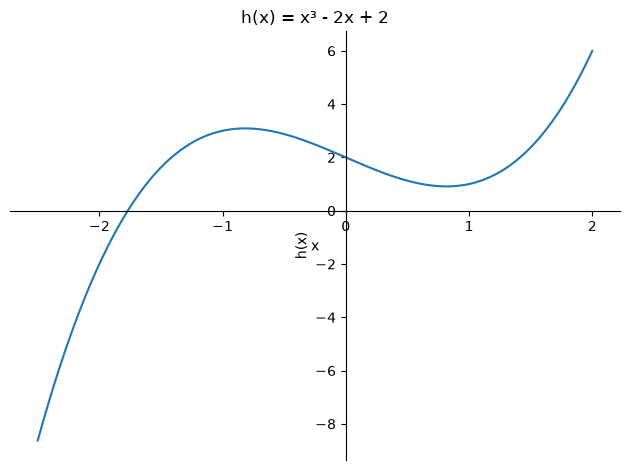

In [46]:
h = x**3 - 2*x + 2

print('h(x) = '), sp.pprint(h)

sp.plot(h, (x, -2.5, 2),
        title='h(x) = x³ - 2x + 2',
        xlabel='x', ylabel='h(x)')

TOL12 = 5e-13   # Precisión de 12 decimales

### Tema 2 (a) — $x_0 = 0$  (Newton entra en un ciclo)

Con $x_0=0$:  $h(0)=2$, $h'(0)=-2 \Rightarrow x_1 = 0 - \tfrac{2}{-2} = 1$.
Luego $h(1)=1$, $h'(1)=1 \Rightarrow x_2 = 1 - \tfrac{1}{1} = 0$.

In [47]:

print('NEWTON — h(x),  x0 = 0')

raiz_h_0 = MetodoNewton(h, xest=0.0, TOL=TOL12)

NEWTON — h(x),  x0 = 0

La función derivada obtenida con sympy es:
   2    
3⋅x  - 2


Tabla de Resultados del Método de Newton
╭────────┬──────────────────┬────────────────────╮
│  Paso  │    Estimación    │  Error Aproximado  │
├────────┼──────────────────┼────────────────────┤
│   1    │ 1.00000000000000 │      1.00e+00      │
├────────┼──────────────────┼────────────────────┤
│   2    │ 0.00000000000000 │      1.00e+00      │
├────────┼──────────────────┼────────────────────┤
│   3    │ 1.00000000000000 │      1.00e+00      │
├────────┼──────────────────┼────────────────────┤
│   4    │ 0.00000000000000 │      1.00e+00      │
├────────┼──────────────────┼────────────────────┤
│   5    │ 1.00000000000000 │      1.00e+00      │
├────────┼──────────────────┼────────────────────┤
│   6    │ 0.00000000000000 │      1.00e+00      │
├────────┼──────────────────┼────────────────────┤
│   7    │ 1.00000000000000 │      1.00e+00      │
├────────┼──────────────────┼────────────────────┤
│   8

### Tema 2 (b) — $x_0 = 0.7$  (región "mala")

In [48]:

print('NEWTON — h(x),  x0 = 0.7')

raiz_h_07 = MetodoNewton(h, xest=0.7, TOL=TOL12)

NEWTON — h(x),  x0 = 0.7

La función derivada obtenida con sympy es:
   2    
3⋅x  - 2


Tabla de Resultados del Método de Newton
╭────────┬───────────────────┬────────────────────╮
│  Paso  │    Estimación     │  Error Aproximado  │
├────────┼───────────────────┼────────────────────┤
│   1    │ 2.47924528301887  │      1.78e+00      │
├────────┼───────────────────┼────────────────────┤
│   2    │ 1.73225005724538  │      7.47e-01      │
├────────┼───────────────────┼────────────────────┤
│   3    │ 1.19905839472415  │      5.33e-01      │
├────────┼───────────────────┼────────────────────┤
│   4    │ 0.62591062281917  │      5.73e-01      │
├────────┼───────────────────┼────────────────────┤
│   5    │ 1.83044417947264  │      1.20e+00      │
├────────┼───────────────────┼────────────────────┤
│   6    │ 1.27501735027813  │      5.55e-01      │
├────────┼───────────────────┼────────────────────┤
│   7    │ 0.74574460117366  │      5.29e-01      │
├────────┼───────────────────┼────────

### Tema 2 (c) — $x_0 = -1.5$  (converge a la raíz real)

In [49]:

print('NEWTON — h(x),  x0 = -1.5')

raiz_h_m15 = MetodoNewton(h, xest=-1.5, TOL=TOL12)

NEWTON — h(x),  x0 = -1.5

La función derivada obtenida con sympy es:
   2    
3⋅x  - 2


Tabla de Resultados del Método de Newton
╭────────┬───────────────────┬────────────────────╮
│  Paso  │    Estimación     │  Error Aproximado  │
├────────┼───────────────────┼────────────────────┤
│   1    │ -1.84210526315789 │      3.42e-01      │
├────────┼───────────────────┼────────────────────┤
│   2    │ -1.77282691999216 │      6.93e-02      │
├────────┼───────────────────┼────────────────────┤
│   3    │ -1.76930129255045 │      3.53e-03      │
├────────┼───────────────────┼────────────────────┤
│   4    │ -1.76929235429601 │      8.94e-06      │
├────────┼───────────────────┼────────────────────┤
│   5    │ -1.76929235423863 │      5.74e-11      │
├────────┼───────────────────┼────────────────────┤
│   6    │ -1.76929235423863 │      0.00e+00      │
╰────────┴───────────────────┴────────────────────╯
Después de  6 pasos, la raíz aproximada con Newton es: -1.769292354238631




### Tema 2 (d) — Explicación del comportamiento

- **$x_0 = 0$ (ciclo).** El punto inicial cae en una zona donde las tangentes rebotan entre $0$ y $1$ formando un **ciclo de período 2**. Newton no diverge ni converge: queda atrapado. Influye que cerca de esta región la derivada es pequeña (el punto de inflexión está en $x\approx 0.816$, donde $h'=0$). La guardia `max_iter` es esencial para detener el programa.

- **$x_0 = 0.7$ (región mala).** Está muy cerca del punto de inflexión donde $h'\approx 0$. La tangente es casi horizontal, así que su corte con el eje $x$ se va lejísimos. El método se comporta de forma errática (puede divergir o saltar a otra cuenca). Es una zona donde **no conviene iniciar** Newton.

- **$x_0 = -1.5$ (converge).** Está **cerca de la raíz real** y la derivada ahí es grande y de signo estable. Esto cumple las condiciones para la convergencia cuadrática de Newton, y se obtienen los 12 decimales en muy pocas iteraciones.

**Importancia de elegir bien $x_0$.** Newton es muy rápido pero **solo converge localmente**: garantiza convergencia si se parte suficientemente cerca de la raíz y la derivada no se anula. Un mal $x_0$ puede producir ciclos, divergencia o convergencia a una raíz distinta. Conviene graficar la función o usar Bisección para obtener un buen punto de partida.

## Tema 3 — Polinomio $f(x)=x^4-10x^3+33x^2-39x+10$  (30 pts)

$$f(x) = x^4 - 10x^3 + 33x^2 - 39x + 10, \qquad \text{TOL}=10^{-8}$$

Tiene 4 raíces reales. Se localizan gráficamente, se aproximan con Bisección y Newton, y se comparan con las raíces exactas.

### Tema 3 (a) — Gráfica y localización de raíces

Por los cambios de signo: raíz en $[0,1]$, raíz exacta en $x=2$, raíz en $[3,4]$ y raíz en $[4,5]$.

f(x) = 
 4       3       2            
x  - 10⋅x  + 33⋅x  - 39⋅x + 10


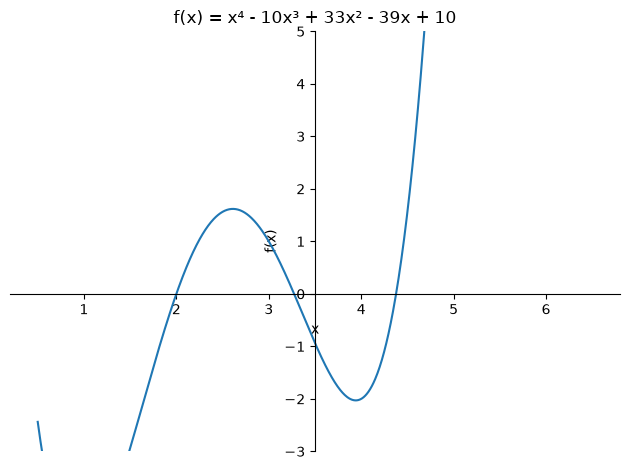


Evaluación en puntos enteros para identificar intervalos:
╭─────┬────────╮
│  x  │  f(x)  │
├─────┼────────┤
│  0  │   10   │
├─────┼────────┤
│  1  │   -5   │
├─────┼────────┤
│  2  │   0    │
├─────┼────────┤
│  3  │   1    │
├─────┼────────┤
│  4  │   -2   │
├─────┼────────┤
│  5  │   15   │
├─────┼────────┤
│  6  │  100   │
╰─────┴────────╯


In [50]:
fp = x**4 - 10*x**3 + 33*x**2 - 39*x + 10

print('f(x) = '), sp.pprint(fp)

sp.plot(fp, (x, 0.5, 6.5),
        title='f(x) = x⁴ - 10x³ + 33x² - 39x + 10',
        xlabel='x', ylabel='f(x)',
        ylim=(-3, 5))

# Evaluamos f en puntos enteros para identificar cambios de signo
fp_num = sp.lambdify(x, fp)
print('\nEvaluación en puntos enteros para identificar intervalos:')
Tabla_eval = []
for xi in range(0, 7):
    Tabla_eval.append([xi, fp_num(xi)])
print(tabulate(Tabla_eval, headers=['x', 'f(x)'], floatfmt=['.0f', '.6f'],
               tablefmt='rounded_grid', numalign='center'))

### Tema 3 (b) — Bisección para las dos primeras raíces

Raíz 1 en $[0,1]$ y raíz 2 ($x=2$) detectada desde $[1.5,\,2.5]$. Tolerancia $10^{-8}$.

In [51]:
TOL8 = 1e-8


print('BISECCIÓN — Raíz 1,  intervalo [0, 1]')

raiz1_bis = MetodoBiseccion(fp, 0, 1, tolerancia=TOL8)


print('BISECCIÓN — Raíz 2,  intervalo [1, 2]')

raiz2_bis = MetodoBiseccion(fp, 1, 2, tolerancia=TOL8)

BISECCIÓN — Raíz 1,  intervalo [0, 1]

Tabla de Resultados del Método de Bisección
╭────────┬────────────┬────────────┬────────────┬──────────┬───────────┬───────────┬───────────────╮
│  Paso  │     a      │     c      │     b      │   f(a)   │   f(c)    │   f(b)    │  Error Aprox  │
├────────┼────────────┼────────────┼────────────┼──────────┼───────────┼───────────┼───────────────┤
│   1    │ 0.00000000 │ 0.50000000 │ 1.00000000 │ 1.00e+01 │ -2.44e+00 │ -5.00e+00 │   5.00e-01    │
├────────┼────────────┼────────────┼────────────┼──────────┼───────────┼───────────┼───────────────┤
│   2    │ 0.00000000 │ 0.25000000 │ 0.50000000 │ 1.00e+01 │ 2.16e+00  │ -2.44e+00 │   2.50e-01    │
├────────┼────────────┼────────────┼────────────┼──────────┼───────────┼───────────┼───────────────┤
│   3    │ 0.25000000 │ 0.37500000 │ 0.50000000 │ 2.16e+00 │ -4.92e-01 │ -2.44e+00 │   1.25e-01    │
├────────┼────────────┼────────────┼────────────┼──────────┼───────────┼───────────┼───────────────┤
│   4   

### Tema 3 (c) — Newton para las dos últimas raíces

Raíz 3 desde $x_0=3.5$ (en $[3,4]$) y raíz 4 desde $x_0=4.5$ (en $[4,5]$).

In [52]:

print('NEWTON — Raíz 3,  x0 = 3')

raiz3_new = MetodoNewton(fp, xest=3.0, TOL=TOL8)

print('NEWTON — Raíz 4,  x0 = 6')

raiz4_new = MetodoNewton(fp, xest=6.0, TOL=TOL8)

NEWTON — Raíz 3,  x0 = 3

La función derivada obtenida con sympy es:
   3       2            
4⋅x  - 30⋅x  + 66⋅x - 39


Tabla de Resultados del Método de Newton
╭────────┬──────────────────┬────────────────────╮
│  Paso  │    Estimación    │  Error Aproximado  │
├────────┼──────────────────┼────────────────────┤
│   1    │ 3.33333333333333 │      3.33e-01      │
├────────┼──────────────────┼────────────────────┤
│   2    │ 3.27433628318583 │      5.90e-02      │
├────────┼──────────────────┼────────────────────┤
│   3    │ 3.27389059863325 │      4.46e-04      │
├────────┼──────────────────┼────────────────────┤
│   4    │ 3.27389055496422 │      4.37e-08      │
├────────┼──────────────────┼────────────────────┤
│   5    │ 3.27389055496420 │      1.38e-14      │
╰────────┴──────────────────┴────────────────────╯
Después de  5 pasos, la raíz aproximada con Newton es:  3.273890554964203


NEWTON — Raíz 4,  x0 = 6

La función derivada obtenida con sympy es:
   3       2            
4⋅x  

### Tema 3 (d) — Raíces exactas y comparación de errores

Se obtienen las raíces exactas con `sp.real_roots` y se calculan el error absoluto y el error relativo porcentual.

In [53]:
print("Metodo Bisección: f(x) = x³ - x - 2,  x0 = 1")

f2a = x**3 - x - 2
a1 = 1
a2 = 2

MetodoBiseccion(f2a,a1,a2, 5e-5)

# Inciso A) Método de Newton

print("Metodo Newton: f(x) = x³ - x - 2,  x0 = 1")
f = x**3 - x - 2
a1 = 1
a2 = 2

MetodoNewton(f, a1, 1e-6)



Metodo Bisección: f(x) = x³ - x - 2,  x0 = 1

Tabla de Resultados del Método de Bisección
╭────────┬────────────┬────────────┬────────────┬───────────┬───────────┬──────────┬───────────────╮
│  Paso  │     a      │     c      │     b      │   f(a)    │   f(c)    │   f(b)   │  Error Aprox  │
├────────┼────────────┼────────────┼────────────┼───────────┼───────────┼──────────┼───────────────┤
│   1    │ 1.00000000 │ 1.50000000 │ 2.00000000 │ -2.00e+00 │ -1.25e-01 │ 4.00e+00 │   5.00e-01    │
├────────┼────────────┼────────────┼────────────┼───────────┼───────────┼──────────┼───────────────┤
│   2    │ 1.50000000 │ 1.75000000 │ 2.00000000 │ -1.25e-01 │ 1.61e+00  │ 4.00e+00 │   2.50e-01    │
├────────┼────────────┼────────────┼────────────┼───────────┼───────────┼──────────┼───────────────┤
│   3    │ 1.50000000 │ 1.62500000 │ 1.75000000 │ -1.25e-01 │ 6.66e-01  │ 1.61e+00 │   1.25e-01    │
├────────┼────────────┼────────────┼────────────┼───────────┼───────────┼──────────┼───────────────┤
│

1.5213797068045676

## Tema 4 — Función por tramos $H(x)$  (25 pts)

$$H(x)=\begin{cases} x^3 - 2x^2 + 3 & x \le 2\\[4pt] x^4 - 4x^3 - x^2 + 23 & 2 \le x < 4\\[4pt] -329 + 25x^2 + x^3 - \dfrac{x^5}{8} & x \ge 4 \end{cases}$$

Derivadas por tramo:

$$H'(x)=\begin{cases} 3x^2 - 4x & x \le 2\\[4pt] 4x^3 - 12x^2 - 2x & 2 \le x < 4\\[4pt] 50x + 3x^2 - \dfrac{5x^4}{8} & x \ge 4 \end{cases}$$

Nota: $H(-1)=0$, por lo que $x=-1$ es una raíz exacta.

H(x) definida por tramos:
⎧      3      2                    
⎪     x  - 2⋅x  + 3       for x ≤ 2
⎪                                  
⎪   4      3    2                  
⎪  x  - 4⋅x  - x  + 23    for x < 4
⎨                                  
⎪   5                              
⎪  x     3       2                 
⎪- ── + x  + 25⋅x  - 329  otherwise
⎪  8                               
⎩                                  


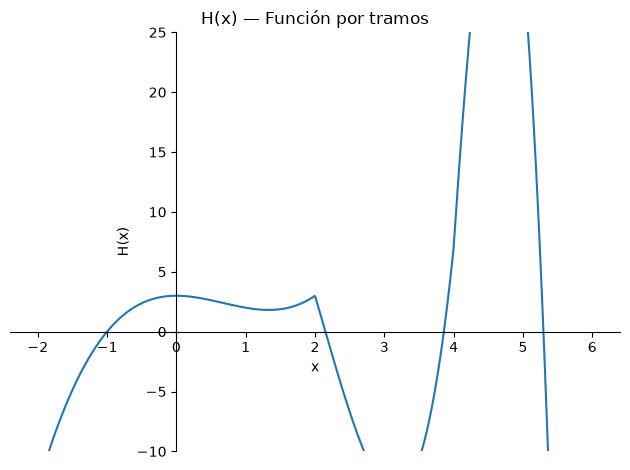

In [54]:
H = sp.Piecewise(
    (x**3 - 2*x**2 + 3,                    x <= 2),
    (x**4 - 4*x**3 - x**2 + 23,            x < 4),
    (-329 + 25*x**2 + x**3 - x**5/8,       True)
)

print('H(x) definida por tramos:')
sp.pprint(H)

sp.plot(H, (x, -2, 6),
        title='H(x) — Función por tramos',
        xlabel='x', ylabel='H(x)',
        ylim=(-10, 25))

### Tema 4 (a) — Gráfica de $H(x)$ en $[-2,6]$

In [56]:
H_num = sp.lambdify(x, H)
print('Evaluación de H(x) para identificar intervalos con raíces:')
Tabla_H = []
for xi in [-2, -1, 0, 1, 2, 3, 4, 5, 5.5, 6]:
    try:
        Tabla_H.append([xi, float(H_num(xi))])
    except:
        Tabla_H.append([xi, 'N/A'])
print(tabulate(Tabla_H, headers=['x', 'H(x)'],
               tablefmt='rounded_grid', numalign='center', floatfmt='.4f'))

Evaluación de H(x) para identificar intervalos con raíces:
╭─────────┬───────────╮
│    x    │   H(x)    │
├─────────┼───────────┤
│ -2.0000 │ -13.0000  │
├─────────┼───────────┤
│ -1.0000 │  0.0000   │
├─────────┼───────────┤
│ 0.0000  │  3.0000   │
├─────────┼───────────┤
│ 1.0000  │  2.0000   │
├─────────┼───────────┤
│ 2.0000  │  3.0000   │
├─────────┼───────────┤
│ 3.0000  │ -13.0000  │
├─────────┼───────────┤
│ 4.0000  │  7.0000   │
├─────────┼───────────┤
│ 5.0000  │  30.3750  │
├─────────┼───────────┤
│ 5.5000  │ -35.4805  │
├─────────┼───────────┤
│ 6.0000  │ -185.0000 │
╰─────────┴───────────╯


Por la gráfica y los valores: una raíz exacta en $x=-1$ (cuenca $[-2,-0.5]$) y otra raíz en $[2,3]$ porque $H(2)=3>0$ y $H(3)=-13<0$.

Como $H$ y $H'$ son funciones de numpy por tramos (no expresiones de SymPy), se definen **versiones específicas** de Bisección y Newton que reciben funciones de Python directamente.

### Tema 4 (b) — Newton para las dos primeras raíces

Raíz 1 con $x_0=-1.5$ y raíz 2 con $x_0=2.5$.

In [58]:
print('=' * 60)
print('NEWTON — H(x),  Raíz 1,  x0 = -1')
print('=' * 60)
raiz_H1_new = MetodoNewton(H, xest=-1.0, TOL=1e-10)

print('=' * 60)
print('NEWTON — H(x),  Raíz 2,  x0 = 1.5')
print('=' * 60)
raiz_H2_new = MetodoNewton(H, xest=1.5, TOL=1e-10)

NEWTON — H(x),  Raíz 1,  x0 = -1

La función derivada obtenida con sympy es:
⎧        2                      
⎪     3⋅x  - 4⋅x       for x ≤ 2
⎪                               
⎪    3       2                  
⎪ 4⋅x  - 12⋅x  - 2⋅x   for x < 4
⎨                               
⎪     4                         
⎪  5⋅x       2                  
⎪- ──── + 3⋅x  + 50⋅x  otherwise
⎪   8                           
⎩                               


Tabla de Resultados del Método de Newton
╭────────┬───────────────────┬────────────────────╮
│  Paso  │    Estimación     │  Error Aproximado  │
├────────┼───────────────────┼────────────────────┤
│   1    │ -1.00000000000000 │      0.00e+00      │
╰────────┴───────────────────┴────────────────────╯
Después de  1 pasos, la raíz aproximada con Newton es: -1.000000000000000


NEWTON — H(x),  Raíz 2,  x0 = 1.5

La función derivada obtenida con sympy es:
⎧        2                      
⎪     3⋅x  - 4⋅x       for x ≤ 2
⎪                               
⎪   

### Tema 4 (c) — Bisección para las dos primeras raíces

Raíz 1 en $[-2,\,0]$ (contiene a $x=-1$) y raíz 2 en $[2,\,3]$ ($H(2)=3>0$, $H(3)=-13<0$).

In [59]:
print('=' * 60)
print('BISECCIÓN — H(x),  Raíz 1')
print('=' * 60)
raiz_H1_bis = MetodoBiseccion(H, -2, 0, tolerancia=1e-10)

print('=' * 60)
print('BISECCIÓN — H(x),  Raíz 2')
print('=' * 60)
raiz_H2_bis = MetodoBiseccion(H, 1, 2, tolerancia=1e-10)

print('\nResumen de raíces de H(x):')
print(f'  Raíz 1 — Newton: {raiz_H1_new:.12f}   Bisección: {raiz_H1_bis:.12f}')
print(f'  Raíz 2 — Newton: {raiz_H2_new:.12f}   Bisección: {raiz_H2_bis:.12f}')

BISECCIÓN — H(x),  Raíz 1

Tabla de Resultados del Método de Bisección
El Método de Bisección falla: no hay cambio de signo en el intervalo.

╭────────┬─────┬─────────────┬─────┬───────────┬──────────┬──────────┬───────────────╮
│  Paso  │  a  │      c      │  b  │   f(a)    │   f(c)   │   f(b)   │  Error Aprox  │
├────────┼─────┼─────────────┼─────┼───────────┼──────────┼──────────┼───────────────┤
│   1    │ -2  │ -1.00000000 │  0  │ -1.30e+01 │ 0.00e+00 │ 3.00e+00 │   1.00e+00    │
╰────────┴─────┴─────────────┴─────┴───────────┴──────────┴──────────┴───────────────╯

 Después de   1 pasos, la raíz aproximada con Bisección es:  -1.000000000000000

BISECCIÓN — H(x),  Raíz 2

Tabla de Resultados del Método de Bisección
El Método de Bisección falla: no hay cambio de signo en el intervalo.

╭────────┬─────┬────────────┬─────┬──────────┬──────────┬──────────┬───────────────╮
│  Paso  │  a  │     c      │  b  │   f(a)   │   f(c)   │   f(b)   │  Error Aprox  │
├────────┼─────┼────────────┼